In [ ]:
!pip install --upgrade transformers

In [1]:
import pandas as pd
import numpy as np
import transformers
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

In [2]:
df = pd.read_csv('/content/dataset_with_text.csv')
df

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness,text
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"anxiety and nervousnessPatient presents with ,..."
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"shortness of breathPatient presents with , dep..."
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"anxiety and nervousnessPatient presents with ,..."
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"anxiety and nervousnessPatient presents with ,..."
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"anxiety and nervousnessPatient presents with ,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31347,concussion,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"vomitingPatient presents with , nauseaPatient ..."
31348,concussion,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"nauseaPatient presents with , double visionPat..."
31349,concussion,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"difficulty speakingPatient presents with , nau..."
31350,concussion,0,0,0,0,0,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"dizzinessPatient presents with , difficulty sp..."


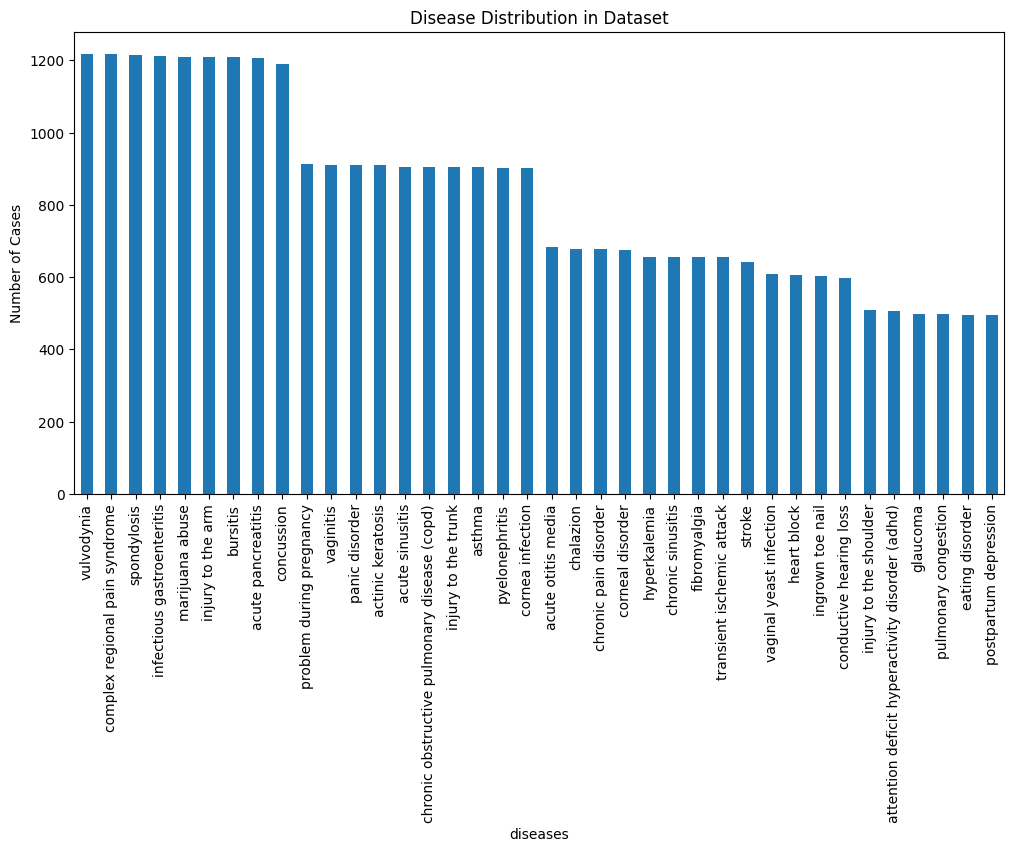

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your dataframe is called df and the disease column is 'label' or 'disease'
disease_counts = df["diseases"].value_counts()

# Plot
plt.figure(figsize=(12, 6))
disease_counts.plot(kind="bar")
plt.title("Disease Distribution in Dataset")
plt.xlabel("diseases")
plt.ylabel("Number of Cases")
plt.xticks(rotation=90)
plt.show()

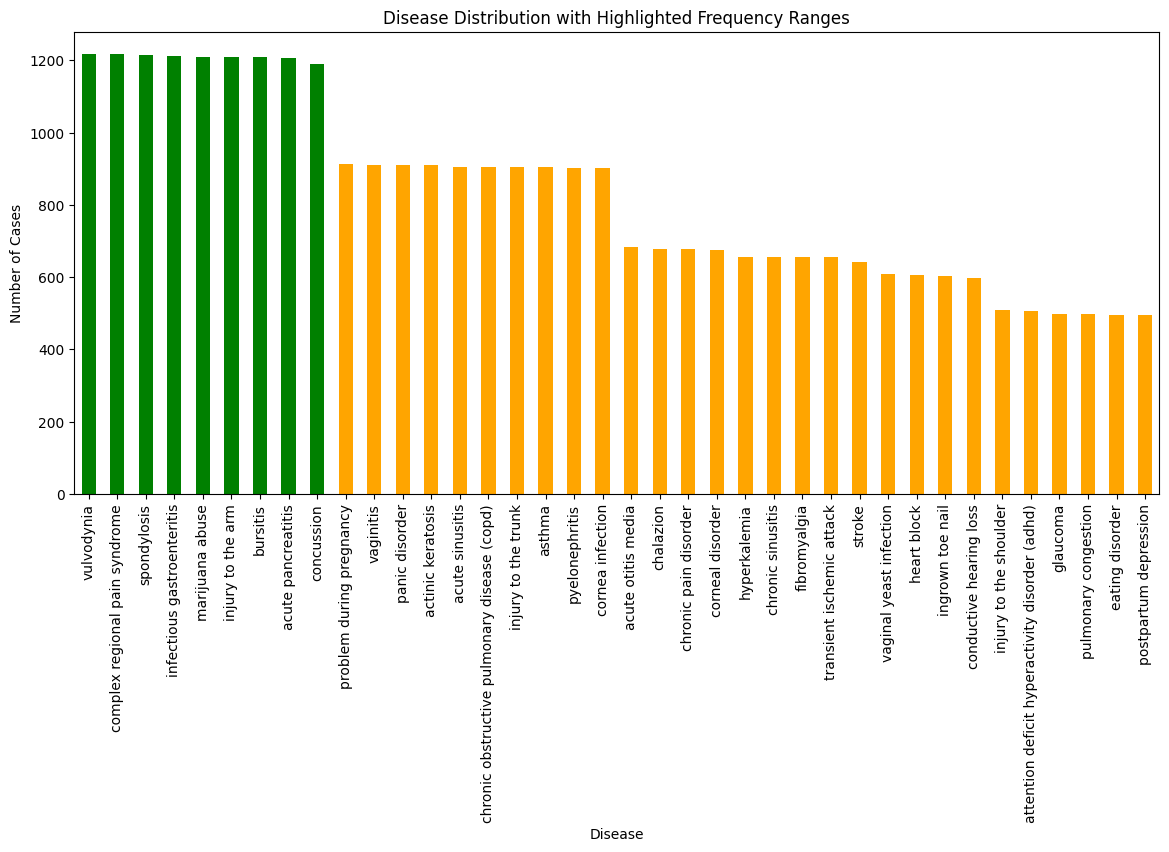

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Example: use your dataframe and disease column
disease_counts = df["diseases"].value_counts()

colors = []
for count in disease_counts:
    if count > 1000:
        colors.append("green")
    elif   100 < count <= 1000:
        colors.append("orange")
    else:
        colors.append("red")


plt.figure(figsize=(14, 6))
disease_counts.plot(kind="bar", color=colors)
plt.title("Disease Distribution with Highlighted Frequency Ranges")
plt.xlabel("Disease")
plt.ylabel("Number of Cases")
plt.xticks(rotation=90)
plt.show()

In [11]:
df.isnull()

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness,text
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31347,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
31348,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
31349,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
31350,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
df_2 = df.dropna()

In [12]:
df.isnull().sum()

,0
diseases,0
anxiety and nervousness,0
depression,0
shortness of breath,0
depressive or psychotic symptoms,0
...,...
back swelling,0
ankle stiffness or tightness,0
ankle weakness,0
neck weakness,0


In [ ]:
disease_counts = df_2["diseases"].value_counts()

print(disease_counts)

diseases
vulvodynia                        1218
complex regional pain syndrome    1217
spondylosis                       1216
infectious gastroenteritis        1212
marijuana abuse                   1210
                                  ... 
obesity                              3
dengue fever                         3
hashimoto thyroiditis                2
turner syndrome                      1
diabetes                             1
Name: count, Length: 161, dtype: int64


In [ ]:
disease_distribution = df_2["diseases"].value_counts(normalize=True) * 100
print(disease_distribution.head(35))

diseases
vulvodynia                                         2.492072
complex regional pain syndrome                     2.490026
spondylosis                                        2.487980
infectious gastroenteritis                         2.479795
marijuana abuse                                    2.475703
injury to the arm                                  2.473657
bursitis                                           2.471611
acute pancreatitis                                 2.469565
concussion                                         2.436829
problem during pregnancy                           1.868031
panic disorder                                     1.859847
actinic keratosis                                  1.859847
vaginitis                                          1.859847
chronic obstructive pulmonary disease (copd)       1.853708
acute sinusitis                                    1.853708
injury to the trunk                                1.851662
asthma                         

In [ ]:
valid_diseases = disease_distribution[disease_distribution > 1].index

df_filter = df_2[df_2["diseases"].isin(valid_diseases)]

df_filter.to_csv("filtered_dataset.csv", index=False)

print("Original size:", len(df_2))
print("Filtered size:", len(df_filter))

Original size: 48875
Filtered size: 31352


# Narrative style dataset

In [ ]:
def row_to_text(row):
    symptoms = [col for col in df_filter.columns[1:-1] if row[col] == 1]  # skip diseases and label
    if not symptoms:
        return "No significant symptoms."
    return "Patient presents with " + ", ".join(symptoms) + "."

df_filter["text"] = df_filter.apply(row_to_text, axis=1)

print(df_filter[["diseases", "text"]].sample(5, random_state=42))

                             diseases  \
41632               injury to the arm   
42500  complex regional pain syndrome   
43309  complex regional pain syndrome   
20074         vaginal yeast infection   
4244                         glaucoma   

                                                    text  
41632  Patient presents with wrist pain, arm pain, ar...  
42500  Patient presents with leg pain, hand or finger...  
43309  Patient presents with abnormal involuntary mov...  
20074  Patient presents with suprapubic pain, vaginal...  
4244   Patient presents with diminished vision, pain ...  


/tmp/ipython-input-1332304406.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filter["text"] = df_filter.apply(row_to_text, axis=1)


In [ ]:
print(df_filter.head()[["diseases", "text"]])

         diseases                                               text
0  panic disorder  Patient presents with: anxiety and nervousness...
1  panic disorder  Patient presents with: shortness of breath, de...
2  panic disorder  Patient presents with: anxiety and nervousness...
3  panic disorder  Patient presents with: anxiety and nervousness...
4  panic disorder  Patient presents with: anxiety and nervousness...


In [ ]:
print(df_filter)

             diseases  anxiety and nervousness  depression  \
0      panic disorder                        1           0   
1      panic disorder                        0           0   
2      panic disorder                        1           1   
3      panic disorder                        1           0   
4      panic disorder                        1           1   
...               ...                      ...         ...   
47790      concussion                        0           0   
47791      concussion                        0           0   
47792      concussion                        0           0   
47793      concussion                        0           0   
47794      concussion                        0           0   

       shortness of breath  depressive or psychotic symptoms  \
0                        1                                 1   
1                        1                                 1   
2                        1                                 1   

In [ ]:
df_filter.to_csv("dataset_with_text.csv", index=False)

In [ ]:
df_text = pd.read_csv("/content/dataset_with_text.csv")
df_text

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness,text
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"anxiety and nervousnessPatient presents with ,..."
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"shortness of breathPatient presents with , dep..."
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"anxiety and nervousnessPatient presents with ,..."
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"anxiety and nervousnessPatient presents with ,..."
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"anxiety and nervousnessPatient presents with ,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31347,concussion,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"vomitingPatient presents with , nauseaPatient ..."
31348,concussion,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"nauseaPatient presents with , double visionPat..."
31349,concussion,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"difficulty speakingPatient presents with , nau..."
31350,concussion,0,0,0,0,0,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"dizzinessPatient presents with , difficulty sp..."


In [ ]:
df = pd.read_csv('/content/dataset_with_text.csv')
df_new = df[['diseases', 'text']]

df_new.to_csv('new_file.csv', index=False)

df_new

,diseases,text
0,panic disorder,"anxiety and nervousnessPatient presents with ,..."
1,panic disorder,"shortness of breathPatient presents with , dep..."
2,panic disorder,"anxiety and nervousnessPatient presents with ,..."
3,panic disorder,"anxiety and nervousnessPatient presents with ,..."
4,panic disorder,"anxiety and nervousnessPatient presents with ,..."
...,...,...
31347,concussion,"vomitingPatient presents with , nauseaPatient ..."
31348,concussion,"nauseaPatient presents with , double visionPat..."
31349,concussion,"difficulty speakingPatient presents with , nau..."
31350,concussion,"dizzinessPatient presents with , difficulty sp..."


In [13]:
sample_df = df.sample(n=15000, random_state=42)

sample_df

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness,text
26315,injury to the arm,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"wrist painPatient presents with , arm painPati..."
27163,complex regional pain syndrome,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"leg painPatient presents with , hand or finger..."
27972,complex regional pain syndrome,0,0,0,0,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,abnormal involuntary movementsPatient presents...
12267,vaginal yeast infection,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"suprapubic painPatient presents with , vaginal..."
2213,glaucoma,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"diminished visionPatient presents with , pain ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18905,bursitis,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"leg painPatient presents with , hip painPatien..."
17970,marijuana abuse,1,1,0,1,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"anxiety and nervousnessPatient presents with ,..."
6451,fibromyalgia,0,0,0,0,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"sharp chest painPatient presents with , hip pa..."
15564,cornea infection,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"symptoms of eyePatient presents with , pain in..."


In [17]:
sample_df_2= df.sample(n=10000, random_state=42)

sample_df_2

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness,text
26315,injury to the arm,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"wrist painPatient presents with , arm painPati..."
27163,complex regional pain syndrome,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"leg painPatient presents with , hand or finger..."
27972,complex regional pain syndrome,0,0,0,0,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,abnormal involuntary movementsPatient presents...
12267,vaginal yeast infection,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"suprapubic painPatient presents with , vaginal..."
2213,glaucoma,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"diminished visionPatient presents with , pain ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20757,actinic keratosis,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"skin swellingPatient presents with , abnormal ..."
23100,spondylosis,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"hip painPatient presents with , paresthesiaPat..."
9547,infectious gastroenteritis,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"vomitingPatient presents with , diarrheaPatien..."
24642,heart block,0,0,0,0,0,0,0,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"chest tightnessPatient presents with , irregul..."


In [ ]:
label_encoder = LabelEncoder()
df_new['label'] = label_encoder.fit_transform(df_new['diseases'])

/tmp/ipython-input-3269730830.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['label'] = label_encoder.fit_transform(df_new['diseases'])


In [ ]:
train_df_new, test_df_new = train_test_split(df_new, test_size=0.2, stratify=df_new["label"], random_state=42)
train_dataset = Dataset.from_pandas(train_df_new[["text", "label"]])
test_dataset = Dataset.from_pandas(test_df_new[["text", "label"]])

In [ ]:
print(dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))

{'actinic keratosis': 0, 'acute otitis media': 1, 'acute pancreatitis': 2, 'acute sinusitis': 3, 'asthma': 4, 'attention deficit hyperactivity disorder (adhd)': 5, 'bursitis': 6, 'chalazion': 7, 'chronic obstructive pulmonary disease (copd)': 8, 'chronic pain disorder': 9, 'chronic sinusitis': 10, 'complex regional pain syndrome': 11, 'concussion': 12, 'conductive hearing loss': 13, 'cornea infection': 14, 'corneal disorder': 15, 'eating disorder': 16, 'fibromyalgia': 17, 'glaucoma': 18, 'heart block': 19, 'hyperkalemia': 20, 'infectious gastroenteritis': 21, 'ingrown toe nail': 22, 'injury to the arm': 23, 'injury to the shoulder': 24, 'injury to the trunk': 25, 'marijuana abuse': 26, 'panic disorder': 27, 'postpartum depression': 28, 'problem during pregnancy': 29, 'pulmonary congestion': 30, 'pyelonephritis': 31, 'spondylosis': 32, 'stroke': 33, 'transient ischemic attack': 34, 'vaginal yeast infection': 35, 'vaginitis': 36, 'vulvodynia': 37}


# Bio_ClinicalBERT

In [ ]:
Bio_ClinicalBERT = "emilyalsentzer/Bio_ClinicalBERT"
tokenizer = AutoTokenizer.from_pretrained(Bio_ClinicalBERT)

# Tokenization
encodings = tokenizer(
    df_new['text'].tolist(),
    truncation=True,
    padding=True,
    max_length=512,
)

In [ ]:
import torch

class DiseaseDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

dataset = DiseaseDataset(encodings, df_new['label'].tolist())

In [ ]:
num_labels = df_new['label'].nunique()  # number of unique diseases

model = AutoModelForSequenceClassification.from_pretrained(
    Bio_ClinicalBERT,
    num_labels=num_labels
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    #evaluation_strategy="epochs", #try with epochs and steps and also
    save_steps=500,
    save_total_limit=2,
    logging_dir='./logs',
    logging_steps=100,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    #eval_dataset=eval_dataset  #add evaluation dataset
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: lamatarek04 (lamatarek04-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss
100,3.295100
200,1.803500
300,0.950100
400,0.561600
500,0.342400
600,0.281000
700,0.220200
800,0.228100
900,0.184500
1000,0.197700


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
